In [3]:
import pandas as pd

df = pd.read_csv("full_ambiguous_few.csv")
print(df.shape)
df.head()

(468, 19)


,response_id,timestamp_utc,model,temperature,max_output_tokens,prompt_id,run_id,target_word,sense_id,gold_sense,sense_family,context_type,few_shot_policy_id,query_mode,sentence,prompt_text,response_text,predicted_sense,correct
0,run_1,2026-03-20T06:08:05+00:00,gpt-4.1-mini,0,300,direct_zero_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"They sat on the bank after withdrawing cash, w...","Sentence: ""They sat on the bank after withdraw...","In this sentence, the word ""bank"" refers to th...",bank_river,True
1,run_2,2026-03-20T06:08:10+00:00,gpt-4.1-mini,0,300,cot_zero_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"They sat on the bank after withdrawing cash, w...","Sentence: ""They sat on the bank after withdraw...",Step 1: Identify the context of the sentence. ...,bank_river,True
2,run_3,2026-03-20T06:08:12+00:00,gpt-4.1-mini,0,300,direct_few_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"They sat on the bank after withdrawing cash, w...","Sentence: ""The bank approved his mortgage afte...",Answer: a financial institution,bank_fin,False
3,run_4,2026-03-20T06:08:18+00:00,gpt-4.1-mini,0,300,cot_few_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"They sat on the bank after withdrawing cash, w...","Sentence: ""The bank approved his mortgage afte...",Let's analyze the sentence step by step:\n\n1....,bank_river,True
4,run_5,2026-03-20T06:08:23+00:00,gpt-4.1-mini,0,300,direct_zero_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"The bank was quiet that morning, aside from th...","Sentence: ""The bank was quiet that morning, as...","In this sentence, the word ""bank"" refers to th...",bank_river,True


In [5]:
#Creating a subset of only the columns needed
ambig = (
    df[['sentence','query_mode','correct','context_type']]
    .copy()
    .assign(
        prompt_type=df['prompt_id'].str.split('_').str[0],
        shot_type=df['prompt_id'].str.split('_').str[1],
        model=df['model'].str.split('-').str[0],
        correct=df['correct'].astype(int)
    )
)
new_order = ['sentence','model','query_mode','prompt_type',
             'shot_type','context_type','correct']
ambig = ambig[new_order]
ambig.head()

,sentence,model,query_mode,prompt_type,shot_type,context_type,correct
0,"They sat on the bank after withdrawing cash, w...",gpt,api,direct,zero,physical_environment,1
1,"They sat on the bank after withdrawing cash, w...",gpt,api,cot,zero,physical_environment,1
2,"They sat on the bank after withdrawing cash, w...",gpt,api,direct,few,physical_environment,0
3,"They sat on the bank after withdrawing cash, w...",gpt,api,cot,few,physical_environment,1
4,"The bank was quiet that morning, aside from th...",gpt,api,direct,zero,physical_environment,1


In [7]:
ambig.to_csv("ambig_struct.csv",index=False)

In [ ]:
cot = df[df['prompt_id'].str.contains("cot", na=False)]
print(cot.shape)
cot.head()

(234, 19)


,response_id,timestamp_utc,model,temperature,max_output_tokens,prompt_id,run_id,target_word,sense_id,gold_sense,sense_family,context_type,few_shot_policy_id,query_mode,sentence,prompt_text,response_text,predicted_sense,correct
1,run_2,2026-03-20T06:08:10+00:00,gpt-4.1-mini,0,300,cot_zero_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"They sat on the bank after withdrawing cash, w...","Sentence: ""They sat on the bank after withdraw...",Step 1: Identify the context of the sentence. ...,bank_river,True
3,run_4,2026-03-20T06:08:18+00:00,gpt-4.1-mini,0,300,cot_few_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"They sat on the bank after withdrawing cash, w...","Sentence: ""The bank approved his mortgage afte...",Let's analyze the sentence step by step:\n\n1....,bank_river,True
5,run_6,2026-03-20T06:08:26+00:00,gpt-4.1-mini,0,300,cot_zero_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"The bank was quiet that morning, aside from th...","Sentence: ""The bank was quiet that morning, as...",Step-by-step reasoning:\n\n1. Identify the wor...,bank_river,True
7,run_8,2026-03-20T06:08:32+00:00,gpt-4.1-mini,0,300,cot_few_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"The bank was quiet that morning, aside from th...","Sentence: ""He deposited money in the bank.""\nQ...",Step 1: Consider the context of the sentence: ...,bank_river,True
9,run_10,2026-03-20T06:08:40+00:00,gpt-4.1-mini,0,300,cot_zero_v1,1,pitch,pitch_throw,physical_throw,physical_action,physical_motion,same_word_cross_sense,api,It was a curveball pitch that nobody in the ro...,"Sentence: ""It was a curveball pitch that nobod...",Step-by-step reasoning:\n\n1. Identify the con...,pitch_throw,True


In [ ]:
average_length = cot["response_text"].str.len().mean()
average_length

1005.5769230769231

In [ ]:
median_length = cot["response_text"].str.len().median()
median_length

1062.0

In [ ]:
cot.to_csv("cot_ambiguous.csv",index=False)

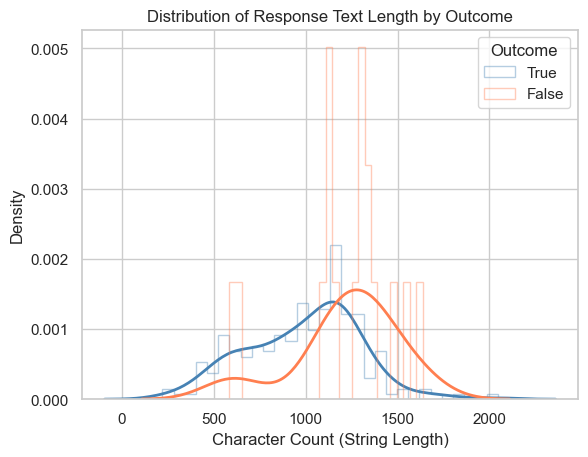

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cot = cot.copy()

# 1. Map labels explicitly using your lambda logic
cot["outcome_label"] = cot["correct"].apply(
    lambda x: "True" if x is True else ("False" if x is False else None)
)

# 2. Drop missing rows FIRST, so empty cells aren't converted to the string "nan"
plot_df = cot.dropna(subset=["response_text", "outcome_label"])

# 3. Calculate text length ONLY on verified text strings
plot_df["text_length"] = plot_df["response_text"].astype(str).str.len()

fig, ax = plt.subplots()
palette = {"True": "steelblue", "False": "coral"}

# 4. Correctly loop and overlay both the steps and the smooth lines
for label in ["True", "False"]:
    subset = plot_df[plot_df["outcome_label"] == label]

    # Plot the histogram step outline
    ax.hist(
        subset["text_length"],
        bins=30,
        density=True,
        alpha=0.4,
        color=palette[label],
        label=label,
        histtype="step",
    )

    # Overlap the density curve for the exact same subset
    sns.kdeplot(
        data=subset,
        x="text_length",
        color=palette[label],
        ax=ax,
        linewidth=2,
    )

ax.set_title("Distribution of Response Text Length by Outcome")
ax.set_xlabel("Character Count (String Length)")
ax.set_ylabel("Density")
ax.legend(title="Outcome")

plt.show()


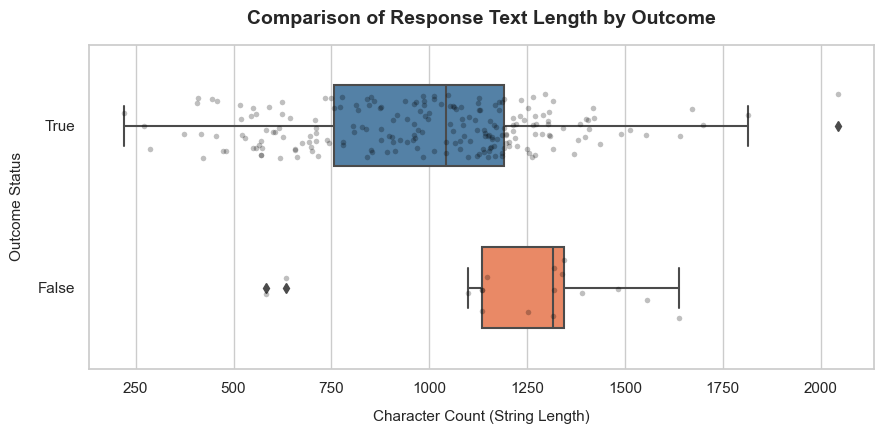

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visual style
sns.set_theme(style="whitegrid")

# 1. Establish the figure size and plot setup
fig, ax = plt.subplots(figsize=(9, 4.5))
palette = {"True": "steelblue", "False": "coral"}

# 2. Render the clean boxplot
sns.boxplot(
    data=plot_df,
    x="text_length",
    y="outcome_label",
    order=["True", "False"],  # Keeps the y-axis ordering consistent
    palette=palette,
    width=0.5,  # Slightly narrower boxes for a modern look
    linewidth=1.5,  # Thicker, cleaner lines
    ax=ax,
)

# 3. Add a strip plot layer to show individual data points (Optional but helpful)
# This lets you see the individual samples without crowding the graph
sns.stripplot(
    data=plot_df,
    x="text_length",
    y="outcome_label",
    order=["True", "False"],
    color="black",
    alpha=0.25,  # Fades the dots back so they don't block the box summary
    size=4,
    jitter=0.2,  # Spreads points out slightly so they don't overlap completely
    ax=ax,
)

# 4. Professional labeling
ax.set_title(
    "Comparison of Response Text Length by Outcome",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
ax.set_xlabel("Character Count (String Length)", fontsize=11, labelpad=10)
ax.set_ylabel("Outcome Status", fontsize=11, labelpad=10)

# Clean up layout bounding boxes
plt.tight_layout()
plt.show()


In [ ]:
# 1. Calculate the full statistical profile for each group
summary = plot_df.groupby("outcome_label")["text_length"].describe()

# 2. Add the Interquartile Range (IQR) explicitly
summary["IQR"] = summary["75%"] - summary["25%"]

# 3. Print the results beautifully formatted
print("=== TEXT LENGTH STATISTICAL SUMMARY ===")
print(summary[["count", "mean", "50%", "min", "max", "IQR"]].to_string())


=== TEXT LENGTH STATISTICAL SUMMARY ===
               count         mean     50%    min     max    IQR
outcome_label                                                  
False           17.0  1224.823529  1315.0  582.0  1637.0  208.0
True           217.0   988.400922  1042.0  221.0  2045.0  435.0


Switching to R for mixed-effects analysis

In [ ]:
.libPaths(c("C:/Users/matth/R/library", .libPaths()))

library(lme4)

Loading required package: Matrix



In [ ]:
library(readr)
setwd("C:/Users/matth/OneDrive/Documents/NCU/Code Files")
sub <- read_csv("responses/cot_ambiguous.csv")
spec(sub)
head(sub)

Rows: 234 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (16): response_id, model, temperature, max_output_tokens, prompt_id, ta...
dbl   (1): run_id
lgl   (2): correct, outcome_label
dttm  (1): timestamp_utc

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cols(
  response_id = col_character(),
  timestamp_utc = col_datetime(format = ""),
  model = col_character(),
  temperature = col_character(),
  max_output_tokens = col_character(),
  prompt_id = col_character(),
  run_id = col_double(),
  target_word = col_character(),
  sense_id = col_character(),
  gold_sense = col_character(),
  sense_family = col_character(),
  context_type = col_character(),
  few_shot_policy_id = col_character(),
  query_mode = col_character(),
  sentence = col_character(),
  prompt_text = col_character(),
  response_text = col_character(),
  predicted_sense = col_character(),
  correct = col_logical(),
  outcome_label = col_logical()
)

response_id,timestamp_utc,model,temperature,max_output_tokens,prompt_id,run_id,target_word,sense_id,gold_sense,sense_family,context_type,few_shot_policy_id,query_mode,sentence,prompt_text,response_text,predicted_sense,correct,outcome_label
<chr>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>
run_2,2026-03-20 06:08:10,gpt-4.1-mini,0,300,cot_zero_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"They sat on the bank after withdrawing cash, watching the water flow by.","Sentence: ""They sat on the bank after withdrawing cash, watching the water flow by."" Question: Explain your reasoning step by step, then state what the word ""bank"" means in this sentence. Answer:","Step 1: Identify the context of the sentence. The sentence is: ""They sat on the bank after withdrawing cash, watching the water flow by."" Step 2: Analyze the possible meanings of the word ""bank."" - One meaning of ""bank"" is a financial institution where people withdraw cash. - Another meaning of ""bank"" is the land alongside a river or stream. Step 3: Consider the actions and setting described. - The phrase ""after withdrawing cash"" suggests they visited a financial institution. - However, the phrase ""watching the water flow by"" indicates they are near a body of water. Step 4: Determine which meaning fits best. - Since they are ""watching the water flow by,"" they must be near a river or stream. - Therefore, ""bank"" here refers to the land alongside the water, not the financial institution. Final answer: In this sentence, the word ""bank"" means the land alongside a river or stream.",bank_river,TRUE,TRUE
run_4,2026-03-20 06:08:18,gpt-4.1-mini,0,300,cot_few_v1,1,bank,bank_river,riverbank,geographic,physical_environment,same_word_cross_sense,api,"They sat on the bank after withdrawing cash, watching the water flow by.","Sentence: ""The bank approved his mortgage after reviewing his credit history."" Question: In this sentence, what does the word ""bank"" mean? Answer: a financial institution Sentence: ""He deposited money in the bank."" Question: In this sentence, what does the word ""bank"" mean? Answer: a financial institution Sentence: ""They ate on the grassy bank overlooking the river."" Question: In this sentence, what does the word ""bank"" mean? Answer: the land alongside a river Sentence: ""The floodwaters rose and spilled over the river bank."" Question: In this sentence, what does the word ""bank"" mean? Answer: the land alongside a river Sentence: ""They sat on the bank after withdrawing cash, watching the water flow by."" Question: Explain your reasoning step by step, then state what the word ""bank"" means in this sentence. Answer:","Let's analyze the sentence step by step: 1. The sentence is: ""They sat on the bank after withdrawing cash, watching the water flow by."" 2. The phrase ""after withdrawing cash"" suggests that the people have just been to a place where money is handled or dispensed. 3. The phrase ""watching the water flow by"" indicates that they are near a body of water, such as a river, stream, or lake. 4. The word ""bank"" can mean either: - A financial institution where money is deposited or withdrawn. - The land alongside a river or body of water. 5. Since they ""withdrew cash,"" they must have been at a financial institution (a bank) to get the money. 6. However, the sentence says ""They sat on the bank,"" which implies sitting on a physical place. 7. The phrase ""watching the water flow by"" strongly suggests that the ""bank"" here refers to the land beside the water. 8. Therefore, the sentence likely means that after withdrawing cash from a financial institution, they went to sit on the riverbank or lakeside bank. Conclusion: In this sentence, the word ""bank"" means the land alongside a river or body of water. Answer: the land alongside a river (or body of water)",bank_river,TRUE,TRUE
run_6,2026-03-20 06:08:26,gpt-4.

In [ ]:
cot_sub <- sub[, c("correct", "sentence", "response_text")]
cot_sub$cot_length <- nchar(cot_sub$response_text)

In [ ]:
head(cot_sub)

correct,sentence,response_text,cot_length
<lgl>,<chr>,<chr>,<int>
TRUE,"They sat on the bank after withdrawing cash, watching the water flow by.","Step 1: Identify the context of the sentence. The sentence is: ""They sat on the bank after withdrawing cash, watching the water flow by."" Step 2: Analyze the possible meanings of the word ""bank."" - One meaning of ""bank"" is a financial institution where people withdraw cash. - Another meaning of ""bank"" is the land alongside a river or stream. Step 3: Consider the actions and setting described. - The phrase ""after withdrawing cash"" suggests they visited a financial institution. - However, the phrase ""watching the water flow by"" indicates they are near a body of water. Step 4: Determine which meaning fits best. - Since they are ""watching the water flow by,"" they must be near a river or stream. - Therefore, ""bank"" here refers to the land alongside the water, not the financial institution. Final answer: In this sentence, the word ""bank"" means the land alongside a river or stream.",907
TRUE,"They sat on the bank after withdrawing cash, watching the water flow by.","Let's analyze the sentence step by step: 1. The sentence is: ""They sat on the bank after withdrawing cash, watching the water flow by."" 2. The phrase ""after withdrawing cash"" suggests that the people have just been to a place where money is handled or dispensed. 3. The phrase ""watching the water flow by"" indicates that they are near a body of water, such as a river, stream, or lake. 4. The word ""bank"" can mean either: - A financial institution where money is deposited or withdrawn. - The land alongside a river or body of water. 5. Since they ""withdrew cash,"" they must have been at a financial institution (a bank) to get the money. 6. However, the sentence says ""They sat on the bank,"" which implies sitting on a physical place. 7. The phrase ""watching the water flow by"" strongly suggests that the ""bank"" here refers to the land beside the water. 8. Therefore, the sentence likely means that after withdrawing cash from a financial institution, they went to sit on the riverbank or lakeside bank. Conclusion: In this sentence, the word ""bank"" means the land alongside a river or body of water. Answer: the land alongside a river (or body of water)",1171
TRUE,"The bank was quiet that morning, aside from the sound of ducks nearby.","Step-by-step reasoning: 1. Identify the word in question: ""bank."" 2. Consider the possible meanings of ""bank"": - A financial institution where people deposit and withdraw money. - The land alongside a river, lake, or other body of water. 3. Analyze the context of the sentence: ""The bank was quiet that morning, aside from the sound of ducks nearby."" 4. The phrase ""aside from the sound of ducks nearby"" suggests the presence of water or a natural environment where ducks would be found. 5. Ducks are commonly found near bodies of water, such as rivers, lakes, or ponds. 6. Therefore, the ""bank"" in this sentence is more likely referring to the land alongside a body of water rather than a financial institution. Answer: In this sentence, the word ""bank"" means the land alongside a river or body of water.",813
TRUE,"The bank was quiet that morning, aside from the sound of ducks nearby.","Step 1: Consider the context of the sentence: ""The bank was quiet that morning, aside from the sound of ducks nearby."" Step 2: The sentence mentions ""the sound of ducks nearby,"" which suggests a natural setting near water, as ducks are commonly found near rivers, lakes, or ponds. Step 3: The word ""bank"" can mean either a financial institution or the land alongside a river or body of water. Step 4: Since the sentence references ducks and a quiet morning, it is more likely referring to a natural environment rather than a financial institution. Step 5: Therefore, ""bank"" in this sentence most likely means the land alongside a river or body of water. Answer: the land alongside a river (or

In [ ]:
length(unique(cot_sub$sentence))

[1] 12

In [ ]:
cot_sub$sentence <- as.factor(cot_sub$sentence)
cot_sub$correct <- as.integer(cot_sub$correct)

glmer(correct ~ cot_length + (1 | sentence),
      family = binomial,
      data = cot_sub)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?"


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ cot_length + (1 | sentence)
   Data: cot_sub
      AIC       BIC    logLik -2*log(L)  df.resid 
  92.9610  103.3270  -43.4805   86.9610       231 
Random effects:
 Groups   Name        Std.Dev.
 sentence (Intercept) 2.215   
Number of obs: 234, groups:  sentence, 12
Fixed Effects:
(Intercept)   cot_length  
   7.406472    -0.002889  
optimizer (Nelder_Mead) convergence code: 0 (OK) ; 0 optimizer warnings; 2 lme4 warnings 

In [ ]:
summary(glmer(correct ~ cot_length + (1 | sentence),
              family = binomial,
              data = cot_sub))

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
"Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?;Model is nearly unidentifiable: large eigenvalue ratio
 - Rescale variables?"


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ cot_length + (1 | sentence)
   Data: cot_sub

      AIC       BIC    logLik -2*log(L)  df.resid 
     93.0     103.3     -43.5      87.0       231 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.0565  0.0529  0.0887  0.1537  1.8947 

Random effects:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 4.906    2.215   
Number of obs: 234, groups:  sentence, 12

Fixed effects:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  7.406472   1.756298   4.217 2.47e-05 ***
cot_length  -0.002889   0.001114  -2.594  0.00948 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
           (Intr)
cot_length -0.783
optimizer (Nelder_Mead) convergence code: 0 (OK)
Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?
Model is nearly unidentifiable: 

In [ ]:
exp(-0.002889)

[1] 0.9971152

In [ ]:
cot_sub$cot_length_scaled <- scale(cot_sub$cot_length)

model <- glmer(correct ~ cot_length_scaled + (1 | sentence),
               family = binomial,
               data = cot_sub)
summary(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ cot_length_scaled + (1 | sentence)
   Data: cot_sub

      AIC       BIC    logLik -2*log(L)  df.resid 
     93.0     103.3     -43.5      87.0       231 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.0565  0.0529  0.0887  0.1537  1.8947 

Random effects:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 4.906    2.215   
Number of obs: 234, groups:  sentence, 12

Fixed effects:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)         4.5011     1.1222   4.011 6.05e-05 ***
cot_length_scaled  -0.8982     0.3462  -2.594  0.00948 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
ct_lngth_sc -0.227

In [ ]:
exp(-0.8982)

[1] 0.4073021

RQ3

In [ ]:
.libPaths(c("C:/Users/matth/R/library", .libPaths()))
library(lme4)
library(readr)
setwd("C:/Users/matth/OneDrive/Documents/NCU/Code Files")
shot <- read_csv("responses/full_ambiguous_few.csv")
spec(shot)
head(show)

Rows: 468 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (16): response_id, model, temperature, max_output_tokens, prompt_id, ta...
dbl   (1): run_id
lgl   (1): correct
dttm  (1): timestamp_utc

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cols(
  response_id = col_character(),
  timestamp_utc = col_datetime(format = ""),
  model = col_character(),
  temperature = col_character(),
  max_output_tokens = col_character(),
  prompt_id = col_character(),
  run_id = col_double(),
  target_word = col_character(),
  sense_id = col_character(),
  gold_sense = col_character(),
  sense_family = col_character(),
  context_type = col_character(),
  few_shot_policy_id = col_character(),
  query_mode = col_character(),
  sentence = col_character(),
  prompt_text = col_character(),
  response_text = col_character(),
  predicted_sense = col_character(),
  correct = col_logical()
)

                                                                                                
1 new("standardGeneric", .Data = function (object)                                              
2 standardGeneric("show"), generic = structure("show", package = "methods"),                    
3     package = "methods", group = list(), valueClass = character(0),                           
4     signature = structure("object", simpleOnly = TRUE), default = new("derivedDefaultMethod", 
5         .Data = function (object)                                                             
6         showDefault(object), target = new("signature", .Data = "ANY",                         

In [ ]:
install.packages("ggplot2", repos = "https://cloud.r-project.org")


Installing package into 'C:/Users/matth/R/library'
(as 'lib' is unspecified)

also installing the dependencies 'farver', 'labeling', 'RColorBrewer', 'viridisLite', 'gtable', 'isoband', 'S7', 'scales'




package 'farver' successfully unpacked and MD5 sums checked
package 'labeling' successfully unpacked and MD5 sums checked
package 'RColorBrewer' successfully unpacked and MD5 sums checked
package 'viridisLite' successfully unpacked and MD5 sums checked
package 'gtable' successfully unpacked and MD5 sums checked
package 'isoband' successfully unpacked and MD5 sums checked
package 'S7' successfully unpacked and MD5 sums checked
package 'scales' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\matth\AppData\Local\Temp\RtmpAXw2eF\downloaded_packages


In [ ]:
install.packages("dplyr", repos = "https://cloud.r-project.org")


Installing package into 'C:/Users/matth/R/library'
(as 'lib' is unspecified)

also installing the dependency 'generics'




package 'generics' successfully unpacked and MD5 sums checked
package 'dplyr' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\matth\AppData\Local\Temp\RtmpAXw2eF\downloaded_packages


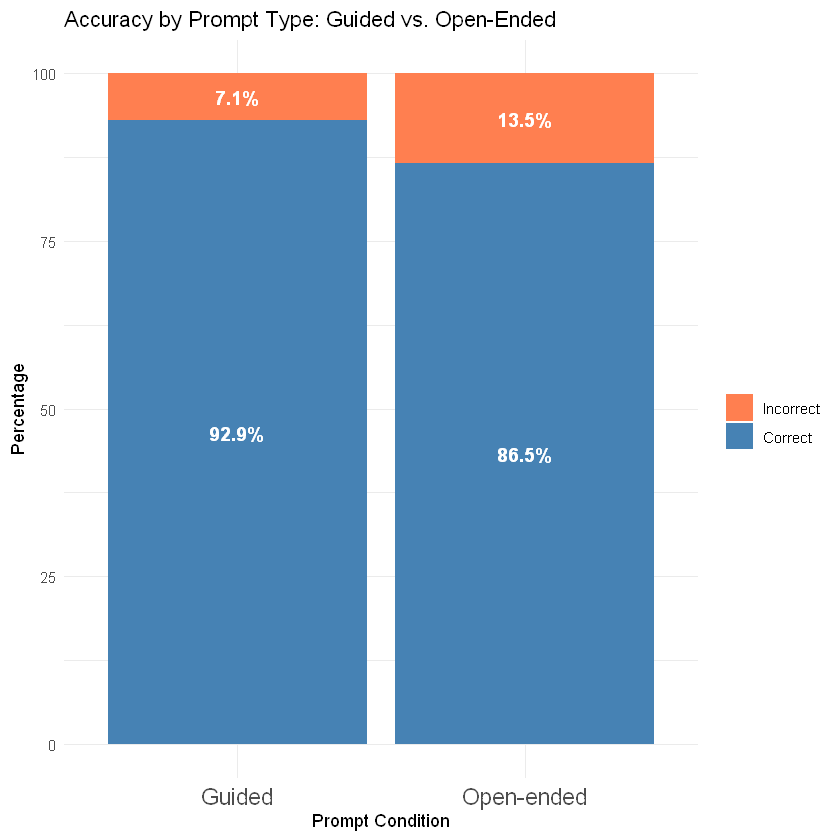

In [ ]:
shot %>%
  mutate(shot_type = case_when(
    grepl("few", prompt_id)  ~ "Guided",
    grepl("zero", prompt_id) ~ "Open-ended"
  )) %>%
  group_by(shot_type, correct) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(shot_type) %>%
  mutate(pct = n / sum(n) * 100,
         label = sprintf("%.1f%%", pct)) %>%
  ggplot(aes(x = shot_type, y = pct, fill = as.factor(correct))) +
  geom_bar(stat = "identity", position = "stack") +
  geom_text(aes(label = label), 
            position = position_stack(vjust = 0.5),
            fontface = "bold", color = "white", size = 4) +
  scale_fill_manual(values = c("TRUE" = "steelblue", "FALSE" = "coral"),
                    labels = c("TRUE" = "Correct", "FALSE" = "Incorrect")) +
  labs(title = "Accuracy by Prompt Type: Guided vs. Open-Ended",
       x = "Prompt Condition",
       y = "Percentage",
       fill = "") +
  theme_minimal()+
theme(axis.text.x = element_text(size = 14))

In [ ]:
table(shot$context_type)


 administrative_action         auditory_event business_communication 
                    36                     36                     72 
    personal_adornment       physical_binding   physical_environment 
                    36                     36                     72 
       physical_motion      physical_tool_use          social_formal 
                    36                     72                     36 
     spatial_structure 
                    36 

In [ ]:
library(lme4)

shot <- shot %>%
  mutate(shot_type = case_when(
    grepl("few", prompt_id)  ~ "Guided",
    grepl("zero", prompt_id) ~ "Open-Ended"
  ),
  shot_type = as.factor(shot_type))

shot$correct <- as.integer(shot$correct)

model <- glmer(
  correct ~ shot_type + query_mode + (1 | sentence),
  data = shot,
  family = binomial
)

print(summary(model), correlation = TRUE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ shot_type + query_mode + (1 | sentence)
   Data: shot

      AIC       BIC    logLik -2*log(L)  df.resid 
    253.5     270.0    -122.7     245.5       464 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-6.9638  0.1177  0.1872  0.2856  0.9579 

Random effects:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 2.229    1.493   
Number of obs: 468, groups:  sentence, 12

Fixed effects:
                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)           3.5140     0.5934   5.922 3.18e-09 ***
shot_typeOpen-Ended  -0.7458     0.3655  -2.040   0.0413 *  
query_modemanual     -0.4130     0.3676  -1.124   0.2611    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr) sh_O-E
sht_typOp-E -0.251       
query_mdmnl -0.210 -0.242


In [ ]:
install.packages("glmmTMB", repos = "https://cloud.r-project.org")

Installing package into 'C:/Users/matth/R/library'
(as 'lib' is unspecified)

also installing the dependencies 'stringi', 'colorspace', 'fracdiff', 'lmtest', 'timeDate', 'urca', 'RcppArmadillo', 'backports', 'purrr', 'stringr', 'tidyr', 'cowplot', 'Deriv', 'forecast', 'modelr', 'microbenchmark', 'broom', 'doBy', 'zoo', 'TMB', 'numDeriv', 'pbkrtest', 'sandwich'




package 'stringi' successfully unpacked and MD5 sums checked
package 'colorspace' successfully unpacked and MD5 sums checked
package 'fracdiff' successfully unpacked and MD5 sums checked
package 'lmtest' successfully unpacked and MD5 sums checked
package 'timeDate' successfully unpacked and MD5 sums checked
package 'urca' successfully unpacked and MD5 sums checked
package 'RcppArmadillo' successfully unpacked and MD5 sums checked
package 'backports' successfully unpacked and MD5 sums checked
package 'purrr' successfully unpacked and MD5 sums checked
package 'stringr' successfully unpacked and MD5 sums checked
package 'tidyr' successfully unpacked and MD5 sums checked
package 'cowplot' successfully unpacked and MD5 sums checked
package 'Deriv' successfully unpacked and MD5 sums checked
package 'forecast' successfully unpacked and MD5 sums checked
package 'modelr' successfully unpacked and MD5 sums checked
package 'microbenchmark' successfully unpacked and MD5 sums checked
package 'broom

In [ ]:
library(lme4)
shot <- shot %>%
  mutate(shot_type = case_when(
    grepl("few", prompt_id)  ~ "Guided",
    grepl("zero", prompt_id) ~ "Open-Ended"
  ),
  shot_type = as.factor(shot_type))

shot$correct <- as.integer(shot$correct)
# install.packages("glmmTMB")
library(glmmTMB)

model3 <- glmmTMB(
  correct ~ shot_type + query_mode + (1 | sentence),
  data = shot,
  family = binomial
)
summary(model3)

 Family: binomial  ( logit )
Formula:          correct ~ shot_type + query_mode + (1 | sentence)
Data: shot

      AIC       BIC    logLik -2*log(L)  df.resid 
    253.5     270.0    -122.7     245.5       464 

Random effects:

Conditional model:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 2.229    1.493   
Number of obs: 468, groups:  sentence, 12

Conditional model:
                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)           3.5140     0.5935   5.921 3.21e-09 ***
shot_typeOpen-Ended  -0.7458     0.3655  -2.040   0.0413 *  
query_modemanual     -0.4130     0.3676  -1.124   0.2611    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [ ]:
  library(lme4)
shot <- shot %>%
  mutate(
    shot_type = case_when(
      grepl("few", prompt_id)  ~ "Guided",
      grepl("zero", prompt_id) ~ "Open-Ended",
      TRUE ~ NA_character_
    ),
    shot_type = relevel(as.factor(shot_type), ref = "Open-Ended")
  )
shot <- shot %>%
  mutate(
    model_type = case_when(
      grepl("gpt", model, ignore.case = TRUE) ~ "gpt",
      grepl("claude", model, ignore.case = TRUE) ~ "claude",
      grepl("deepseek", model, ignore.case = TRUE) ~ "deepseek",
      TRUE ~ NA_character_
    ),
    model_type = as.factor(model_type)
  )
shot$correct <- as.integer(shot$correct)
# install.packages("glmmTMB")
library(glmmTMB)

model4 <- glmmTMB(
  correct ~ shot_type + query_mode + model_type+ (1 | sentence),
  data = shot,
  family = binomial
)
summary(model4)

 Family: binomial  ( logit )
Formula:          
correct ~ shot_type + query_mode + model_type + (1 | sentence)
Data: shot

      AIC       BIC    logLik -2*log(L)  df.resid 
    254.3     279.2    -121.2     242.3       462 

Random effects:

Conditional model:
 Groups   Name        Variance Std.Dev.
 sentence (Intercept) 2.284    1.511   
Number of obs: 468, groups:  sentence, 12

Conditional model:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)          2.3953     0.6499   3.686 0.000228 ***
shot_typeGuided      0.7562     0.3683   2.053 0.040046 *  
query_modemanual    -0.4187     0.3702  -1.131 0.257978    
model_typedeepseek   0.7268     0.4362   1.666 0.095677 .  
model_typegpt        0.5139     0.4186   1.227 0.219638    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [ ]:
exp(0.7562)

[1] 2.130166